# Optimal Estimation Demo

This notebook demonstrates the O2 A optimal-estimation tooling with the aerosol state vector used by the retained validation case.


## What This Demonstrates

The example retrieves aerosol optical depth and aerosol layer mid-pressure from a simulated measurement, then displays the result through `result.plot` accessors. Each plot has its own cell.

The retrieval runs the full-reference case by default. To try the case-owned fastmode path, set `inverse_case.optimisation.fastmode.enabled = True` before calling `oe.disamar_oe(...)`, then inspect `inverse_case.resolved_optimisation()["fastmode"]` to see the exact RTM, adaptive-grid, OE, fast-stage sampling, and final-correction knobs used.


In [1]:
import sys
from pathlib import Path
from time import perf_counter


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "validation").is_dir():
            return candidate
    raise RuntimeError("open this notebook from inside the zdisamar checkout")


REPO_ROOT = find_repo_root()
sys.path[:0] = [str(REPO_ROOT), str(REPO_ROOT / "python")]

import json  # noqa: E402

from zdisamar import reference_data  # noqa: E402
from zdisamar.inverse_method import optimal_estimation as oe  # noqa: E402
from zdisamar.inverse_method.optimal_estimation import o2a as o2a_oe  # noqa: E402
from zdisamar.wavelength_bands import o2a  # noqa: E402

from validation.o2a import baseline as oe_baseline  # noqa: E402
from validation.o2a.measurement_noise import measurement_from_o2a_baseline_noise  # noqa: E402


def show_timed_plot(label, factory):
    start = perf_counter()
    chart = factory()
    elapsed_ms = (perf_counter() - start) * 1000.0
    print(f"{label}: {elapsed_ms:.2f} ms")
    return chart


REFERENCE_PATH = reference_data.path("validation/disamar_o2a_two_state_reference.json")


def load_reference() -> dict:
    with REFERENCE_PATH.open() as handle:
        return json.load(handle)


def case_from_reference(reference: dict, section: str) -> o2a.O2ACase:
    case = o2a.reference_case()
    oe_baseline.configure_case(case)
    scene = reference[section]
    case.aerosol_optical_depth_550_nm = float(scene["aerosol_optical_depth"])
    case.aerosol_layer.mid_pressure_hpa = float(scene["aerosol_layer_mid_pressure_hpa"])
    return case


def build_measurement(case: o2a.O2ACase, reference: dict) -> oe.Measurement:
    _ = reference
    return measurement_from_o2a_baseline_noise(case)


def build_state_vector(
    case: o2a.O2ACase,
    reference: dict,
    profile: oe.PressureAltitudeProfile,
) -> oe.StateVector:
    prior = reference["a_priori"]
    layer_thickness_hpa = case.aerosol_layer.thickness_hpa
    return oe.StateVector(
        [
            oe.AerosolOpticalDepth(
                initial=float(prior["aerosol_optical_depth"]),
                prior=float(prior["aerosol_optical_depth"]),
                variance=1.0,
                lower=0.0,
            ),
            oe.AerosolLayerMidPressure(
                initial=float(prior["aerosol_layer_mid_pressure_hpa"]),
                prior=float(prior["aerosol_layer_mid_pressure_hpa"]),
                variance=float(prior["aerosol_layer_mid_pressure_variance_hpa2"]),
                thickness_hpa=layer_thickness_hpa,
                interval_index_1based=case.aerosol.placement.interval_index_1based,
                pressure_altitude_profile=profile,
            ),
        ]
    )


def run_optimal_estimation_demo() -> oe.Result:
    reference = load_reference()
    truth_case = case_from_reference(reference, "truth")
    inverse_case = case_from_reference(reference, "a_priori")
    measurement = build_measurement(truth_case, reference)
    profile = o2a_oe.pressure_altitude_profile_from_case(inverse_case)
    state_vector = build_state_vector(inverse_case, reference, profile)
    return oe.disamar_oe(
        case=inverse_case,
        measurement=measurement,
        state_vector=state_vector,
        controls=oe.RetrievalControls.from_disamar_retrieval_specs(),
    )

## Run The Retrieval

This cell runs the retrieval. The following cells display the charts directly from `result.plot`.


In [2]:
result = run_optimal_estimation_demo()
{
    "state_names": result.state_names,
    "retrieved_state": list(result.state),
    "iterations": result.iterations,
    "converged": result.converged,
}

{'state_names': ('aerosol_optical_depth', 'aerosol_layer_mid_pressure_hpa'),
 'retrieved_state': [0.2999999675039418, 899.9999369063869],
 'iterations': 4,
 'converged': True}

## Retrieval Convergence


result.plot.convergence(): 0.06 ms


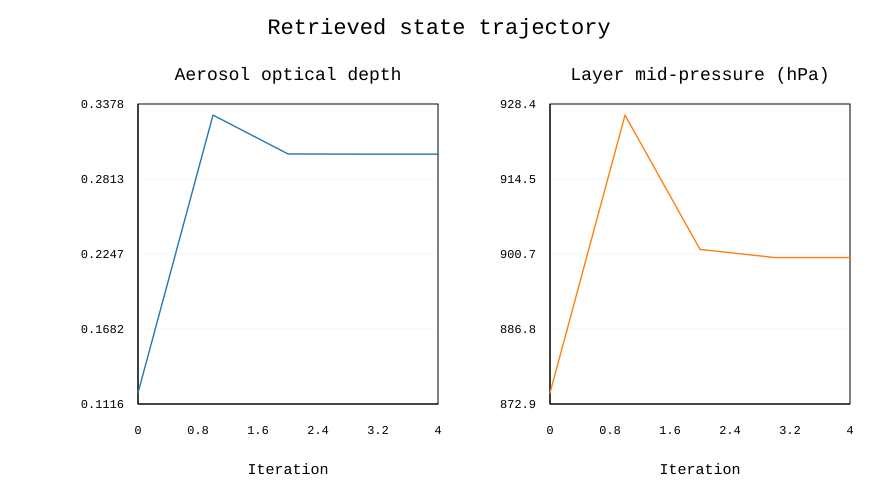

In [3]:
convergence_chart = show_timed_plot("result.plot.convergence()", result.plot.convergence)
convergence_chart

## Measurement Fit


result.plot.measurement_fit(): 1209.41 ms


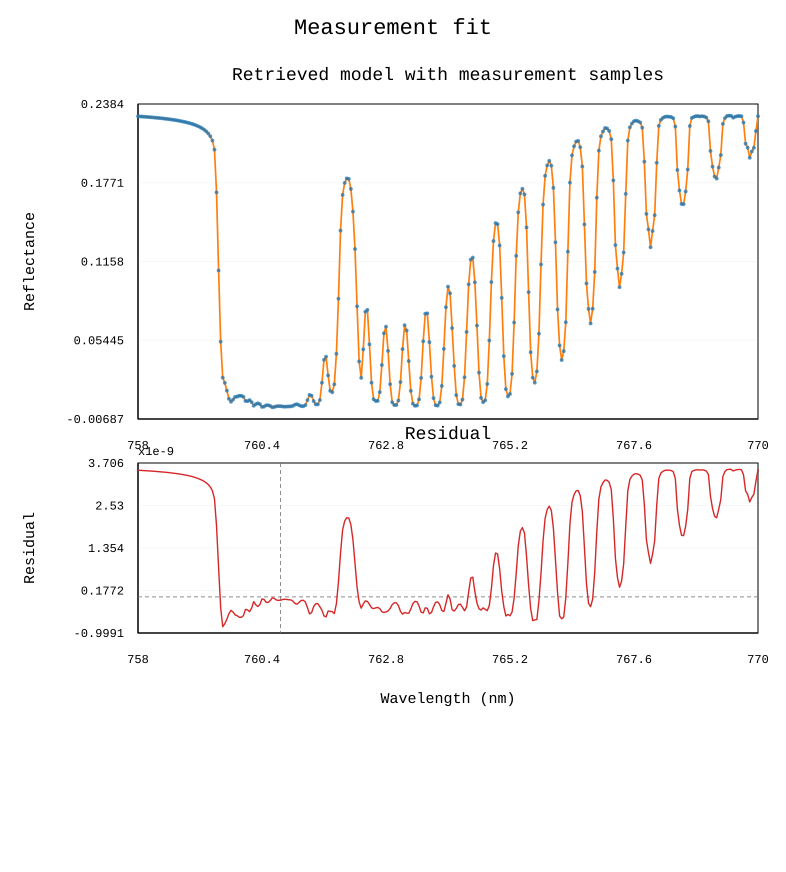

In [4]:
measurement_fit_chart = show_timed_plot(
    "result.plot.measurement_fit()",
    result.plot.measurement_fit,
)
measurement_fit_chart

## Final Reflectance Jacobians


result.plot.jacobian(): 0.63 ms


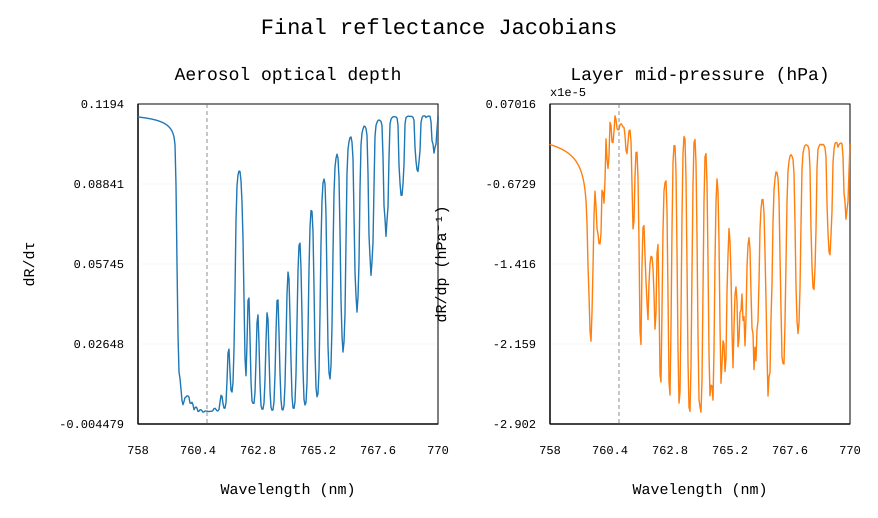

In [5]:
jacobian_chart = show_timed_plot("result.plot.jacobian()", result.plot.jacobian)
jacobian_chart